## Day 1 — Unsupervised Learning & K-Means

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv('car data.csv')

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
numeric_cols = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']

X_numeric = df[numeric_cols]
X_numeric.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
0,2014,3.35,5.59,27000,0
1,2013,4.75,9.54,43000,0
2,2017,7.25,9.85,6900,0
3,2011,2.85,4.15,5200,0
4,2014,4.60,6.87,42450,0


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
X_scaled_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
0,0.128897,-0.258416,-0.236215,-0.256224,-0.174501
1,-0.217514,0.017481,0.221505,0.155911,-0.174501
2,1.168129,0.510154,0.257427,-0.773969,-0.174501
3,-0.910335,-0.356950,-0.403079,-0.817758,-0.174501
4,0.128897,-0.012079,-0.087890,0.141743,-0.174501


In [10]:
print("Mean per column:\n", X_scaled_df.mean().round(2))
print("\nStd per column:\n", X_scaled_df.std().round(2))

Mean per column:
 Year            -0.0
Selling_Price   -0.0
Present_Price   -0.0
Kms_Driven       0.0
Owner            0.0
dtype: float64

Std per column:
 Year             1.0
Selling_Price    1.0
Present_Price    1.0
Kms_Driven       1.0
Owner            1.0
dtype: float64


#### Why Scaling Matters Here

`Present_Price` and `Selling_Price` are measured in lakhs (large 
magnitude), while `Owner` ranges only 0-3 and `Year` is a 4-digit number 
with a narrow range. Without scaling, distance-based methods (K-Means, 
PCA) would be dominated entirely by whichever column happens to have the 
largest raw magnitude (`Kms_Driven` here), regardless of its actual 
importance. `StandardScaler` transforms every column to have mean 0 and 
standard deviation 1, giving each feature equal weight before applying 
any unsupervised technique.

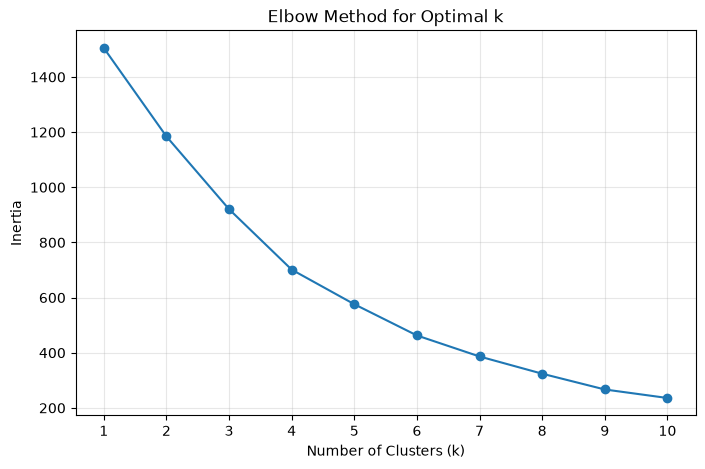

In [11]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()

#### Reading the Elbow

Inertia drops sharply from k=1 to k=4 (1508 → ~700), then the rate of 
decrease flattens noticeably from k=4 onward, with only modest 
incremental improvement through k=10.

The elbow appears around **k = 4** — this is where the curve transitions 
from steep decline to a much gentler slope. Adding clusters beyond 4 
continues to reduce inertia, but each additional cluster buys 
increasingly little, suggesting the data has roughly 4 natural groupings 
rather than more granular structure.

**Chosen value: k = 4**

In [12]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df['Cluster'] = clusters
df.groupby('Cluster')[numeric_cols].mean()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Cluster,,,,,
0,2014.827907,4.147209,5.872400,26588.167442,0.000000
1,2011.454545,2.018182,5.171818,41304.000000,1.181818
2,2009.338983,2.623898,7.689898,71201.728814,0.000000
3,2014.812500,20.899375,32.688125,46837.937500,0.000000


With k=4 selected, each car is now assigned to one of 4 clusters based on 
its scaled numeric features. The next step is to examine what 
distinguishes each cluster (e.g. newer/cheaper vs. older/expensive cars) 
and visualize the result, typically after reducing to 2D with PCA for 
plotting.

In [14]:
candidate_ks = [3, 4]

for k in candidate_ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: Silhouette Score = {score:.4f}")

k=3: Silhouette Score = 0.4379
k=4: Silhouette Score = 0.4122


#### Silhouette Score Results

| k | Silhouette Score |
|---|---|
| 3 | 0.4379 |
| 4 | 0.4122 |

**Chosen k = 3**

k=3 achieves a higher silhouette score (0.4379 vs. 0.4122), indicating 
tighter, better-separated clusters despite the elbow plot's slightly 
sharper bend at k=4. This is a common and expected discrepancy — the 
elbow method is a visual heuristic based on inertia alone, while 
silhouette score directly measures cluster quality (cohesion and 
separation), making it the more reliable criterion when the two disagree.

In [15]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df['Cluster'] = clusters

In [18]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.38297707 0.32514126]
Total variance captured: 0.7081183339884476


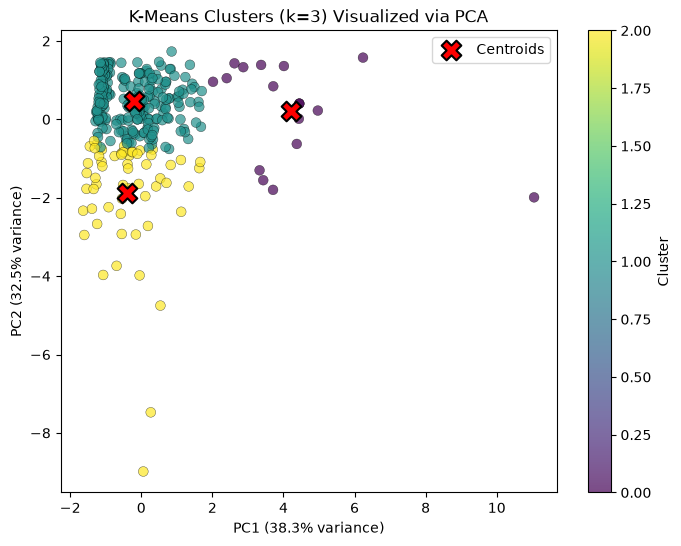

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', 
                       alpha=0.7, s=50, edgecolor='k', linewidth=0.3)

# Drawing the cluster centers (after converting them to the same PCA space)
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', 
            s=200, edgecolor='black', linewidth=1.5, label='Centroids')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters (k=3) Visualized via PCA')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

#### Visualizing the Clusters in 2D

The PCA projection shows one large, dense cluster (teal, Cluster 1 — 
budget/low-mileage cars) tightly packed near the origin, while Clusters 0 
(purple, premium) and 2 (yellow, older/high-mileage) are more spread out 
and overlap more with each other along PC1.

Several notable outliers are visible — particularly one purple point far 
right (~PC1=11), likely an unusually expensive car, and several yellow 
points with very negative PC2 (down to ~−9), likely cars with extreme 
mileage or age relative to the rest of the data. These outliers pull 
their respective cluster centroids away from their main point mass, 
visible in how the yellow centroid sits noticeably above the bulk of 
yellow points.

The visible overlap between clusters (especially 0 and 2) is consistent 
with the moderate silhouette score (0.44) — clusters are reasonably 
distinct but not perfectly separated, and only 71% of total variance is 
captured in this 2D view, so some separation exists in dimensions not 
shown here.

In [20]:
df.groupby('Cluster')[numeric_cols].mean().round(2)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Cluster,,,,,
0,2014.88,20.54,31.64,45435.71,0.00
1,2014.68,4.04,5.85,27600.88,0.00
2,2009.16,2.43,7.53,70877.64,0.21


#### Interpreting the Clusters

| Cluster | Year | Price | Present Price | Kms | Owner | Profile |
|---|---|---|---|---|---|---|
| 0 | 2014.9 | 20.54 | 31.64 | 45,436 | 0.00 | Premium cars |
| 1 | 2014.7 | 4.04 | 5.85 | 27,601 | 0.00 | Budget, low-mileage |
| 2 | 2009.2 | 2.43 | 7.53 | 70,878 | 0.21 | Older, high-mileage |

Clustering separates cars along two independent factors: **price tier** 
(Cluster 0's premium pricing vs. Cluster 1's budget range, despite 
similar age) and **age/wear** (Cluster 2's older, high-mileage, 
multi-owner profile). This matches the PCA result, where two components 
of comparable variance (38% / 33%) reflect these distinct dimensions 
rather than one dominant factor.